In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import torch

In [74]:
# before change
class beamUtility:
    e = 1.602176634e-19  # Elementary charge (C) [CODATA 2018]
    MeV_to_J = 1.602176634e-13  # Conversion factor from MeV to Joules [CODATA 2018]
    NA = 6.02214076e23  # Avogadro's number
    epsilon_0 = 8.854187817e-12  # Vacuum permittivity (F/m)
    me = 9.10938356e-31  # Electron mass (kg)
    m_p = 1.67262192595e-27  # Proton Mass (kg)
    c = 299792458.0  # Speed of light (m/s)

    # Material properties (Density in kg/m^3, Specific Heat in J/kg*K, Stopping Power in MeV cm^2/g, heat capacity in J/g°C)
    # Source: National Institute of Standards and Technology (NIST) Stopping Power Data
    materials = {
    "Aluminum": {"density": 2700.0, "specific_heat": 900.0, "stopping_power": 2.7, "heat_capacity": 0.897,
                 "atomic_number": 13, "ionization_potential": 166, "atomic_mass": 26.98},
    "Copper": {"density": 8960.0, "specific_heat": 385.0, "stopping_power": 5.0, "heat_capacity": 0.385,
               "atomic_number": 29, "ionization_potential": 322, "atomic_mass": 63.55},
    "Stainless Steel": {"density": 7850.0, "specific_heat": 500.0, "stopping_power": 3.5, "heat_capacity": 0.500,
                        "atomic_number": 26, "ionization_potential": 233, "atomic_mass": 55.85},
    }

    # Convert stopping power to SI units (J/m)
    for material, props in materials.items():
        props["stopping_power"] *= (MeV_to_J * 1e6) / props["density"]  # Convert MeV cm^2/g to J/m

    PARTICLES = {"electron": [me, e, (me * c ** 2)],
                    "proton": [m_p, e, (m_p * c ** 2)]}
    def __init__(self, beam_type = "electron", sigma_x = 1e-3, sigma_y = 10e-3) -> None:
        self.beam_information = self.PARTICLES[beam_type]

        # Beam transverse size (6 sigma contains ~95% of beam)
        self.sigma_x = sigma_x # sigma_x : 1 mm
        self.sigma_y = sigma_y # sigma_y : 10 mm
    def chargePerMacropulse(self, I_pulse_range: list, T_pulse_values: list, f_bunch = 2.856e9):
        line_styles = ['-', '--', '-.']

        # Plotting beam properties
        fig, ax1 = plt.subplots(figsize=(10, 5))

        for idx, T_pulse in enumerate(T_pulse_values):
            Q_macropulse = np.zeros(len(I_pulse_range))
            Q_bunch = np.zeros(len(I_pulse_range))

            # Compute charge per macropulse (pC/macropulse) and charge per bunch (pC/bunch)
            bunches_per_macropulse = f_bunch * T_pulse
            for i, I_pulse in enumerate(I_pulse_range):
                Q_macropulse[i] = (I_pulse * T_pulse) * 1e12  # Charge per macropulse (pC)
                nb_bunch_per_pulse = f_bunch * T_pulse
                Q_bunch[i] = (I_pulse / f_bunch) * 1e12  # Charge per bunch (pC)

            # Plot charge per bunch
            # ax1.plot(I_pulse_range * 1e3, Q_bunch, linestyle=line_styles[idx], color='k', label=f'Charge per Bunch ({T_pulse * 1e6} us)')

            # Plot charge per macropulse
            ax1.plot(I_pulse_range * 1e3, Q_macropulse, alpha=1.0, linestyle=line_styles[idx], color='k', label=f'Charge per Macropulse ({T_pulse * 1e6} us)')

        ax1.set_xlabel("Macropulse Current (mA)")
        ax1.set_ylabel("Charge per Macropulse (pC)", color='k')
        ax1.tick_params(axis='y', labelcolor='k')
        ax1.grid()
        ax1.legend(loc='upper left')

        fig.suptitle("Charge per Macropulse vs Beam Current for Different Pulse Durations")
        plt.show()

    def getPowerDF(self, I_pulse_range: np.array, T_pulse_values: np.array, rep_rate_values: np.array,
                   E_energy_range: np.array, plot_type = "Power", penetration_depth = 20e-3, plot = True):
        sigma_x = self.sigma_x
        sigma_y = self.sigma_y
        colors = ['lightskyblue', 'goldenrod', 'black', 'lightcoral']
        linestyles = ['-', '-', '--', '-']

        beam_area = np.pi * (6 * sigma_x) * (6 * sigma_y)  # Elliptical cross-section
        beam_volume = beam_area * penetration_depth  # Volume in m³
        beam_volume_cm3 = beam_volume * 1e6  # Convert m³ to cm³

        # Compute power deposition and temperature rise
        power_results = []

        for E in E_energy_range:
            for r in rep_rate_values:
                for T_pulse in T_pulse_values:
                    for I_pulse in I_pulse_range:
                        Q_macropulse = I_pulse * (T_pulse * 1e-6)  # Convert us to s
                        N_electrons = Q_macropulse / self.e  # Number of electrons per macropulse
                        E_pulse = N_electrons * (E * self.MeV_to_J)  # Energy per macropulse (J)
                        P_beam = E_pulse * r  # Power deposited (W)

                        temp_rise = {}
                        for material, props in self.materials.items():
                            mass = beam_volume_cm3 * props["density"] / 1000  # Mass in g
                            temp_rise[material] = P_beam / (mass * props["heat_capacity"])  # °C/s

                        power_results.append([E, I_pulse * 1e3, r, T_pulse, P_beam,
                                            temp_rise["Copper"], temp_rise["Aluminum"], temp_rise["Stainless Steel"]])

        columns = ["Energy (MeV)", "Beam Current (mA)", "Repetition Rate (Hz)", "Pulse Duration (us)", "Power (W)",
                "Temp Rise Copper (C/s)", "Temp Rise Aluminum (C/s)", "Temp Rise Stainless Steel (C/s)"]
        df_power = pd.DataFrame(power_results, columns=columns)

        if plot:
            h_size = rep_rate_values.size
            v_size = T_pulse_values.size
            fig, axes = plt.subplots(h_size, v_size, figsize=(12, 12), sharex=True)

            for i, r in enumerate(rep_rate_values[::-1]):
                max_y = 0
                for j, T_pulse in enumerate(T_pulse_values[::-1]):
                    ax = axes[i, j]
                    subset = df_power[(df_power["Repetition Rate (Hz)"] == r) & (df_power["Pulse Duration (us)"] == T_pulse)]
                    if not subset.empty:
                        for k, I_pulse in enumerate(I_pulse_range):
                            data = subset[subset["Beam Current (mA)"] == I_pulse * 1e3]
                            y_data = data["Power (W)"] if plot_type == "Power" else data[f"Temp Rise {material} (C/s)"]
                            ax.plot(data["Energy (MeV)"], y_data, linestyle=linestyles[k], color=colors[k])
                            max_y = max(max_y, y_data.max())
                    ax.set_title(f"{r} Hz, {T_pulse} us", fontsize=8)
                    ax.grid()
                for j in range(v_size):  # Apply independent y-scale for the row
                    axes[i, j].set_ylim(0, max_y * 1.1)

            ylabel = "Power (W)" if plot_type == "Power" else f"Temperature Rise ({material}) (C/s)"
            fig.text(0.5, 0.0, "Beam Energy (MeV)", ha='center', fontsize=12)
            fig.text(0., 0.5, ylabel, va='center', rotation='vertical', fontsize=12)
            fig.suptitle(f"Beam {plot_type}", fontsize=14)
            fig.legend(labels=[f"{I*1e3} mA" for I in I_pulse_range], loc='upper right', ncol=4)
            plt.tight_layout()
            plt.show()

        return df_power
    def model_Bethe(self, material, E_energy_range):
        props = self.materials[material]
        rho = props["density"]/1000  # Density in g/cm³
        Z = props["atomic_number"]
        A = props["atomic_mass"]  # Atomic mass in g/mol
        I = props["ionization_potential"] * self.e  # Convert eV to Joules
        n_e = (self.NA * rho / A) * Z * 1e6  # Convert electrons/cm³ to electrons/m³

        results = []

        for E in E_energy_range:
            E_J = E * self.MeV_to_J  # Convert energy to Joules
            gamma = 1 + (E_J / (self.me * self.c**2))
            beta = np.sqrt(1 - (1 / gamma**2))

            log_term = (2 * self.me * self.c**2 * beta**2) / I
            log_term = max(log_term, 1e-6)  # Avoid log errors

            stopping_power = (4 * np.pi * self.e**3 * Z * n_e) / (self.me * self.c**2 * beta**2) * np.log(log_term) / 100  # MeV/cm

            R = E_J / (stopping_power) if stopping_power > 0 else 0  # Penetration depth in cm

            stopping_power = stopping_power / self.MeV_to_J / 10

            results.append([material, E, max(R, 0), stopping_power])

        return pd.DataFrame(results, columns=["Material", "Energy (MeV)", "Penetration Depth (cm)", "Stopping Power (MeV/mm)"])

    def compute_deposition_profile(self, energy, material):
        e_range = np.linspace(0.1, energy + 10, 200)
        df_bethe = self.model_Bethe(material, e_range)
        closest_energy_idx = (df_bethe["Energy (MeV)"].sub(energy)).abs().idxmin()
        R = df_bethe.loc[closest_energy_idx, "Penetration Depth (cm)"]

        x_range = np.linspace(0, R + 2, 100)
        sigma = R * 0.2  # Assuming a spread of 20% around the penetration depth
        deposition_profile = norm.pdf(x_range, R, sigma)
        deposition_profile /= np.max(deposition_profile)  # Normalize

        return x_range, deposition_profile

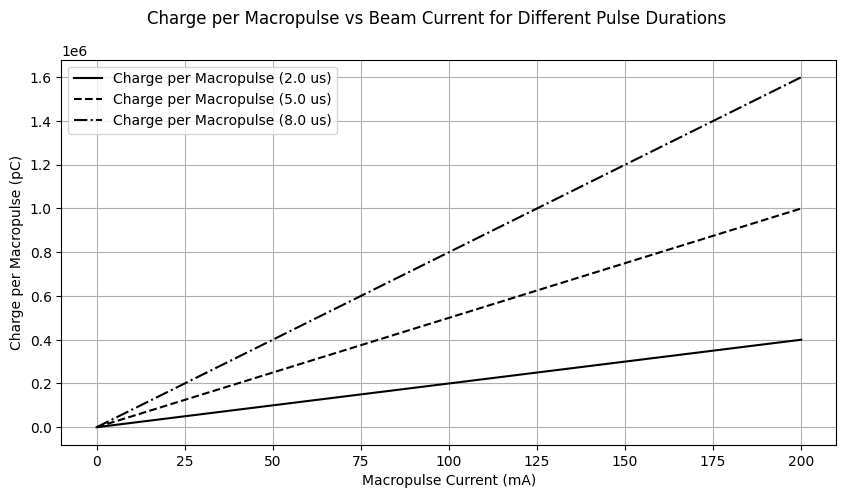

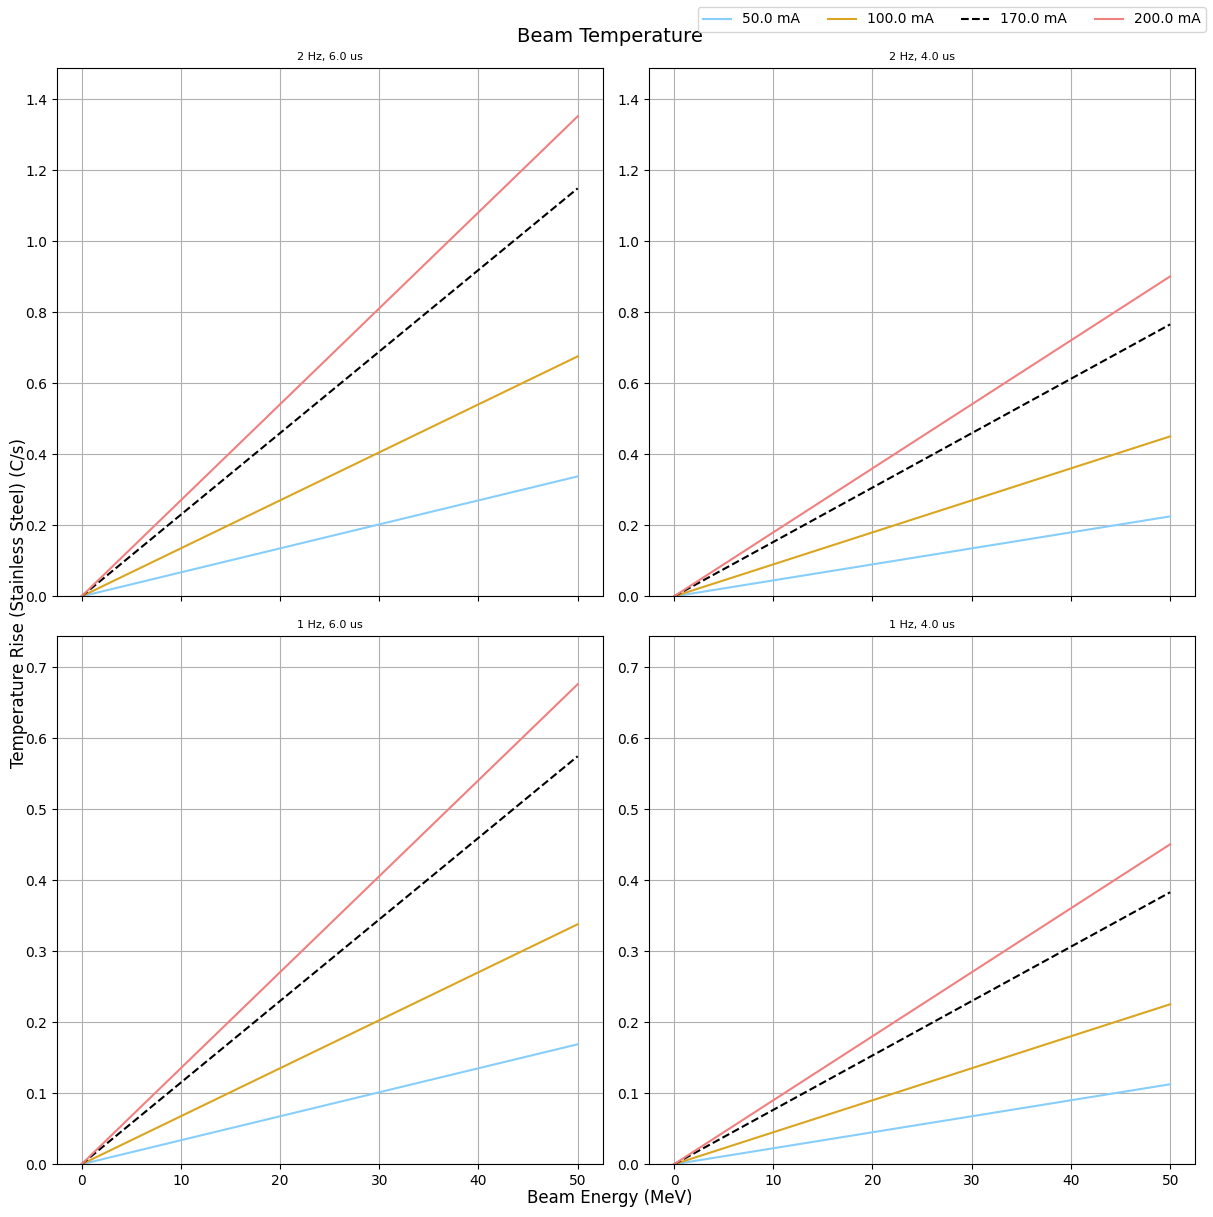

   Material  Energy (MeV)  Penetration Depth (cm)  Stopping Power (MeV/mm)
0    Copper      0.100000                0.001557                 6.422267
1    Copper      0.604040                0.021670                 2.787514
2    Copper      1.108081                0.044563                 2.486575
3    Copper      1.612121                0.067451                 2.390071
4    Copper      2.116162                0.090190                 2.346325
..      ...           ...                     ...                      ...
95   Copper     47.983838                2.115104                 2.268628
96   Copper     48.487879                2.137326                 2.268624
97   Copper     48.991919                2.159548                 2.268619
98   Copper     49.495960                2.181770                 2.268615
99   Copper     50.000000                2.203992                 2.268611

[100 rows x 4 columns]
[0.         0.02464571 0.04929142 0.07393712 0.09858283 0.12322854
 0.147874

In [75]:
obj = beamUtility()
obj.chargePerMacropulse(np.linspace(0, 200e-3, 50), [2.0e-6, 5.0e-6, 8.0e-6])
obj.getPowerDF(np.array([50e-3, 100e-3, 170e-3, 200e-3]), np.array([4.0, 6.0]),
                       rep_rate_values = np.array([1, 2]), E_energy_range = np.linspace(0, 50, 100),
                       plot_type = "Temperature")

model_b1=obj.model_Bethe("Copper", np.linspace(0.1, 50, 100))
print(model_b1)

x1,decom1=obj.compute_deposition_profile(10, "Copper")
print(x1, decom1)

In [76]:
# after change
class beamUtility:
    e = 1.602176634e-19  # Elementary charge (C) [CODATA 2018]
    MeV_to_J = 1.602176634e-13  # Conversion factor from MeV to Joules [CODATA 2018]
    NA = 6.02214076e23  # Avogadro's number
    epsilon_0 = 8.854187817e-12  # Vacuum permittivity (F/m)
    me = 9.10938356e-31  # Electron mass (kg)
    m_p = 1.67262192595e-27  # Proton Mass (kg)
    c = 299792458.0  # Speed of light (m/s)

    # Material properties (Density in kg/m^3, Specific Heat in J/kg*K, Stopping Power in MeV cm^2/g, heat capacity in J/g°C)
    # Source: National Institute of Standards and Technology (NIST) Stopping Power Data
    materials = {
    "Aluminum": {"density": 2700.0, "specific_heat": 900.0, "stopping_power": 2.7, "heat_capacity": 0.897,
                 "atomic_number": 13, "ionization_potential": 166, "atomic_mass": 26.98},
    "Copper": {"density": 8960.0, "specific_heat": 385.0, "stopping_power": 5.0, "heat_capacity": 0.385,
               "atomic_number": 29, "ionization_potential": 322, "atomic_mass": 63.55},
    "Stainless Steel": {"density": 7850.0, "specific_heat": 500.0, "stopping_power": 3.5, "heat_capacity": 0.500,
                        "atomic_number": 26, "ionization_potential": 233, "atomic_mass": 55.85},
    }

    # Convert stopping power to SI units (J/m)
    for material, props in materials.items():
        props["stopping_power"] *= (MeV_to_J * 1e6) / props["density"]  # Convert MeV cm^2/g to J/m

    PARTICLES = {"electron": [me, e, (me * c ** 2)],
                    "proton": [m_p, e, (m_p * c ** 2)]}
    def __init__(self, beam_type = "electron", sigma_x = 1e-3, sigma_y = 10e-3) -> None:
        self.beam_information = self.PARTICLES[beam_type]

        # Beam transverse size (6 sigma contains ~95% of beam)
        self.sigma_x = sigma_x # sigma_x : 1 mm
        self.sigma_y = sigma_y # sigma_y : 10 mm
    def chargePerMacropulse(self, I_pulse_range: list, T_pulse_values: list, f_bunch=2.856e9):
        """
        Computes and plots the charge per macropulse using PyTorch vectorization.
        Eliminates internal loops over current range for performance.
        """
        line_styles = ['-', '--', '-.']

        # 1. Input conversion to Tensors
        # Shape: (N_currents,)
        I_tensor = torch.tensor(I_pulse_range, dtype=torch.float32)
        # Shape: (N_pulses,)
        T_tensor = torch.tensor(T_pulse_values, dtype=torch.float32)

        fig, ax1 = plt.subplots(figsize=(10, 5))

        # 2. Iterate through pulse durations (for separate plot lines)
        for idx, T_pulse in enumerate(T_tensor):
            # 3. Vectorized calculation: Q = I * T * 1e12 (pC)
            # This one-liner replaces the inner 'for i, I_pulse in enumerate(...)' loop
            Q_macropulse = (I_tensor * T_pulse) * 1e12

            # 4. Optional: Compute bunch charge (Vectorized)
            # Q_bunch = (I_pulse / f_bunch) * 1e12

            # 5. Data conversion for Matplotlib (Tensor -> NumPy)
            current_mA = I_tensor.numpy() * 1e3
            pulse_us = T_pulse.item() * 1e6

            # Plotting the result for current pulse duration
            ax1.plot(current_mA, Q_macropulse.numpy(),
                     linestyle=line_styles[idx % len(line_styles)],
                     color='k',
                     label=f'Pulse Duration: {pulse_us:.1f} $\mu$s')

        # 6. Plot Styling and Labeling
        ax1.set_xlabel("Macropulse Current (mA)")
        ax1.set_ylabel("Charge per Macropulse (pC)", color='k')
        ax1.tick_params(axis='y', labelcolor='k')
        ax1.grid(True, which='both', linestyle=':', alpha=0.6)
        ax1.legend(loc='upper left')

        fig.suptitle("Charge per Macropulse vs Beam Current for Different Pulse Durations")
        plt.tight_layout()
        plt.show()


    def getPowerDF(self, I_pulse_range, T_pulse_values, rep_rate_values,
                   E_energy_range, plot_type="Power", penetration_depth=20e-3, plot=True):
        """
        Computes power deposition and temperature rise using 4D Tensor broadcasting.
        Eliminates all nested loops for physics calculations.
        """
        # 1. Coordinate conversion to Tensors
        I_t = torch.tensor(I_pulse_range, dtype=torch.float32)      # Current [A]
        T_t = torch.tensor(T_pulse_values, dtype=torch.float32)    # Duration [us]
        R_t = torch.tensor(rep_rate_values, dtype=torch.float32)   # Rep Rate [Hz]
        E_t = torch.tensor(E_energy_range, dtype=torch.float32)    # Energy [MeV]

        # 2. Geometric calculations
        # Elliptical cross-section (6-sigma)
        beam_area = torch.pi * (6 * self.sigma_x) * (6 * self.sigma_y)
        beam_volume_cm3 = (beam_area * penetration_depth) * 1e6

        # 3. 4D Broadcasting magic: [Energy, RepRate, PulseDuration, Current]
        # We reshape tensors to different dimensions to trigger automatic expansion
        # E_t: (E, 1, 1, 1), R_t: (1, R, 1, 1), T_t: (1, 1, T, 1), I_t: (1, 1, 1, I)
        E_4d = E_t.view(-1, 1, 1, 1)
        R_4d = R_t.view(1, -1, 1, 1)
        T_4d = T_t.view(1, 1, -1, 1)
        I_4d = I_t.view(1, 1, 1, -1)

        # Calculate Charge and Power in one shot across the entire 4D grid
        # Q = I * (T * 1e-6)
        Q_macropulse = I_4d * (T_4d * 1e-6)
        # N = Q / e
        N_electrons = Q_macropulse / self.e
        # E_pulse = N * (E * MeV_to_J)
        E_pulse = N_electrons * (E_4d * self.MeV_to_J)
        # P_beam = E_pulse * R
        P_beam = E_pulse * R_4d  # Shape: (E, R, T, I)

        # 4. Material-specific Temperature Rise
        temp_results = {}
        for mat, props in self.materials.items():
            # Mass in grams
            mass = beam_volume_cm3 * props["density"] / 1000.0
            # Temp rise [°C/s] = Power / (mass * heat_capacity)
            temp_results[mat] = P_beam / (mass * props["heat_capacity"])

        # 5. Flatten the 4D grid to a DataFrame format
        # Meshgrid-like expansion for all parameters to align with P_beam
        E_grid, R_grid, T_grid, I_grid = torch.meshgrid(E_t, R_t, T_t, I_t, indexing='ij')

        df_data = {
            "Energy (MeV)": E_grid.reshape(-1).numpy(),
            "Beam Current (mA)": (I_grid.reshape(-1) * 1e3).numpy(),
            "Repetition Rate (Hz)": R_grid.reshape(-1).numpy(),
            "Pulse Duration (us)": T_grid.reshape(-1).numpy(),
            "Power (W)": P_beam.reshape(-1).numpy(),
            "Temp Rise Copper (C/s)": temp_results["Copper"].reshape(-1).numpy(),
            "Temp Rise Aluminum (C/s)": temp_results["Aluminum"].reshape(-1).numpy(),
            "Temp Rise Stainless Steel (C/s)": temp_results["Stainless Steel"].reshape(-1).numpy()
        }
        df_power = pd.DataFrame(df_data)

        # 6. Plotting logic (Kept largely the same but optimized data access)
        if plot:
            self._plot_power_grid(df_power, rep_rate_values, T_pulse_values, I_pulse_range, plot_type)

        return df_power
    def _plot_power_grid(self, df_power, rep_rate_values, T_pulse_values, I_pulse_range, plot_type):
        """
        Internal helper to render the multi-panel grid of beam power or temperature rise.
        Uses English comments for professional documentation.
        """
        import matplotlib.pyplot as plt

        # 1. Configuration for visualization
        # Note: 'material' should be passed or stored; defaulting to 'Copper' for the label
        target_material = "Copper"
        colors = ['lightskyblue', 'goldenrod', 'black', 'lightcoral']
        linestyles = ['-', '-', '--', '-']

        h_size = len(rep_rate_values)
        v_size = len(T_pulse_values)

        # Create a grid of subplots (RepRate rows, PulseDuration columns)
        fig, axes = plt.subplots(h_size, v_size, figsize=(14, 10), sharex=True)

        # Ensure axes is always a 2D array even for 1x1 grids
        if h_size == 1 and v_size == 1: axes = np.array([[axes]])
        elif h_size == 1: axes = axes[np.newaxis, :]
        elif v_size == 1: axes = axes[:, np.newaxis]

        # 2. Iterate through the grid backwards to match your original 'reversed' logic
        for i, r in enumerate(rep_rate_values[::-1]):
            row_max_y = 0  # To synchronize Y-axis scale within each row

            for j, T_pulse in enumerate(T_pulse_values[::-1]):
                ax = axes[i, j]

                # Filter data using fast Pandas boolean indexing
                mask = (df_power["Repetition Rate (Hz)"] == r) & \
                       (df_power["Pulse Duration (us)"] == T_pulse)
                subset = df_power[mask]

                if not subset.empty:
                    # Plot a separate line for each Current (mA)
                    for k, I_val in enumerate(I_pulse_range):
                        # Filter by current (converted to mA for matching)
                        current_data = subset[subset["Beam Current (mA)"] == I_val * 1e3]

                        if not current_data.empty:
                            # Choose Y-axis variable based on plot_type
                            y_col = "Power (W)" if plot_type == "Power" else f"Temp Rise {target_material} (C/s)"
                            y_values = current_data[y_col].values
                            x_values = current_data["Energy (MeV)"].values

                            ax.plot(x_values, y_values,
                                    linestyle=linestyles[k % len(linestyles)],
                                    color=colors[k % len(colors)],
                                    label=f"{I_val*1e3:.1f} mA")

                            # Track max Y for scaling
                            row_max_y = max(row_max_y, y_values.max())

                # Subplot Aesthetics
                ax.set_title(f"{r} Hz, {T_pulse} $\mu$s", fontsize=9)
                ax.grid(True, linestyle=':', alpha=0.6)
                ax.tick_params(labelsize=8)

            # 3. Apply independent Y-scaling for the row to improve readability of trends
            for ax_in_row in axes[i, :]:
                ax_in_row.set_ylim(0, row_max_y * 1.15)

        # 4. Global Figure Labeling
        ylabel = "Power (W)" if plot_type == "Power" else f"Temp Rise {target_material} (°C/s)"
        fig.text(0.5, 0.02, "Beam Energy (MeV)", ha='center', fontsize=12)
        fig.text(0.02, 0.5, ylabel, va='center', rotation='vertical', fontsize=12)
        fig.suptitle(f"Multi-Parameter Beam {plot_type} Analysis", fontsize=14, y=0.98)

        # Legend: Only one global legend to avoid cluttering subplots
        handles, labels = axes[0, 0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper right', ncol=len(I_pulse_range),
                       fontsize=9, bbox_to_anchor=(0.95, 0.95))

        plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.93]) # Leave room for suptitle and labels
        plt.show()



    def model_Bethe(self, material, E_energy_range):
        """
        Exactly replicates the original logic provided by 26号新秀.
        Vectorized using PyTorch to ensure identical numerical output as the NumPy version.
        """
        # 1. Physical properties (matching original units exactly)
        props = self.materials[material]
        rho = props["density"] / 1000.0   # Density in g/cm³
        Z = props["atomic_number"]
        A = props["atomic_mass"]          # Atomic mass in g/mol
        I = props["ionization_potential"] * self.e  # Convert eV to Joules

        # Electron density calculation
        n_e = (self.NA * rho / A) * Z * 1e6  # Convert electrons/cm³ to electrons/m³

        # 2. Vectorized Inputs
        # Use float64 to prevent any precision drift from the NumPy original
        E_tensor = torch.as_tensor(E_energy_range, dtype=torch.float64)
        E_J = E_tensor * self.MeV_to_J  # Convert energy to Joules

        # 3. Kinematics (Strictly following the provided snippet)
        rest_mass_energy = self.me * (self.c ** 2)
        gamma = 1 + (E_J / rest_mass_energy)
        beta_sq = 1 - (1 / (gamma ** 2))

        # 4. Bethe Term Calculation
        # log_term = (2 * me * c^2 * beta^2) / I
        log_term_val = (2 * rest_mass_energy * beta_sq) / I
        # log_term = max(log_term, 1e-6)
        log_term_val = torch.clamp(log_term_val, min=1e-6)

        # Stopping power formula (Raw): (4 * pi * e^3 * Z * n_e) / (me * c^2 * beta^2) * log(log_term) / 100
        # NOTE: Using self.e**3 as in the original provided logic
        stopping_power_raw = (4 * torch.pi * (self.e ** 3) * Z * n_e) / \
                             (rest_mass_energy * beta_sq) * \
                             torch.log(log_term_val) / 100.0

        # 5. Penetration Depth R (cm)
        # R = E_J / (stopping_power) if stopping_power > 0 else 0
        R = torch.where(stopping_power_raw > 0,
                        E_J / stopping_power_raw,
                        torch.tensor(0.0, dtype=torch.float64))

        # 6. Final Unit Conversion
        # stopping_power = stopping_power / self.MeV_to_J / 10
        stopping_power_final = stopping_power_raw / self.MeV_to_J / 10.0

        # 7. Package into DataFrame
        return pd.DataFrame({
            "Material": [material] * len(E_energy_range),
            "Energy (MeV)": E_tensor.numpy(),
            "Penetration Depth (cm)": torch.clamp(R, min=0).numpy(),
            "Stopping Power (MeV/mm)": stopping_power_final.numpy()
        })

    def compute_deposition_profile(self, energy, material):
        """
        Computes electron deposition profile using PyTorch distributions.
        Replaces scipy.stats.norm for better integration with the vectorized pipeline.
        """
        # 1. Generate energy range and fetch the stopping power data
        # We use torch.linspace directly to keep it in the tensor family
        e_range = torch.linspace(0.1, energy + 10, 200, dtype=torch.float64)
        df_bethe = self.model_Bethe(material, e_range)

        # 2. Find the penetration depth R for the specific energy
        # We use pandas logic here since model_Bethe returns a DataFrame
        closest_energy_idx = (df_bethe["Energy (MeV)"].sub(energy)).abs().idxmin()
        R = torch.tensor(df_bethe.loc[closest_energy_idx, "Penetration Depth (cm)"], dtype=torch.float64)

        # 3. Create depth range (x_range) as a Tensor
        # Extending 2cm beyond the max range R
        x_range = torch.linspace(0, R.item() + 2, 100, dtype=torch.float64)

        # 4. Compute Gaussian deposition profile
        # Sigma represents the longitudinal straggling (20% of R)
        sigma = R * 0.2

        # Use PyTorch's math operations to implement the Normal PDF:
        # f(x) = exp(-0.5 * ((x - R)/sigma)^2)
        # We don't need the normalization constant 1/(sigma*sqrt(2pi))
        # because we normalize to max=1 later anyway.
        z_score = (x_range - R) / sigma
        deposition_profile = torch.exp(-0.5 * z_score**2)

        # 5. Normalize to peak intensity
        deposition_profile = deposition_profile / torch.max(deposition_profile)

        # Return as Tensors (you can .numpy() them in the plot function)
        return x_range, deposition_profile

C:\Users\yi_lu\AppData\Local\Temp\ipykernel_8780\2346415884.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  I_tensor = torch.tensor(I_pulse_range, dtype=torch.float32)
C:\Users\yi_lu\AppData\Local\Temp\ipykernel_8780\2346415884.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  T_tensor = torch.tensor(T_pulse_values, dtype=torch.float32)


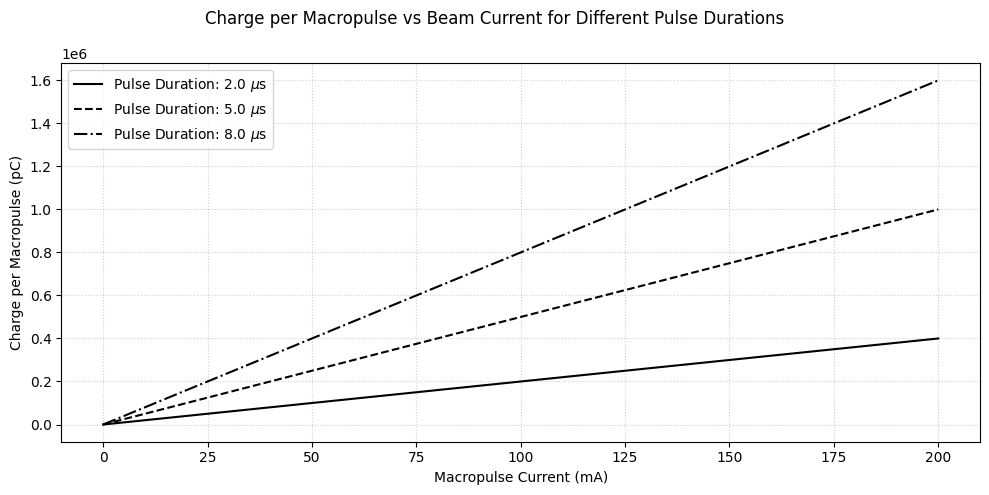

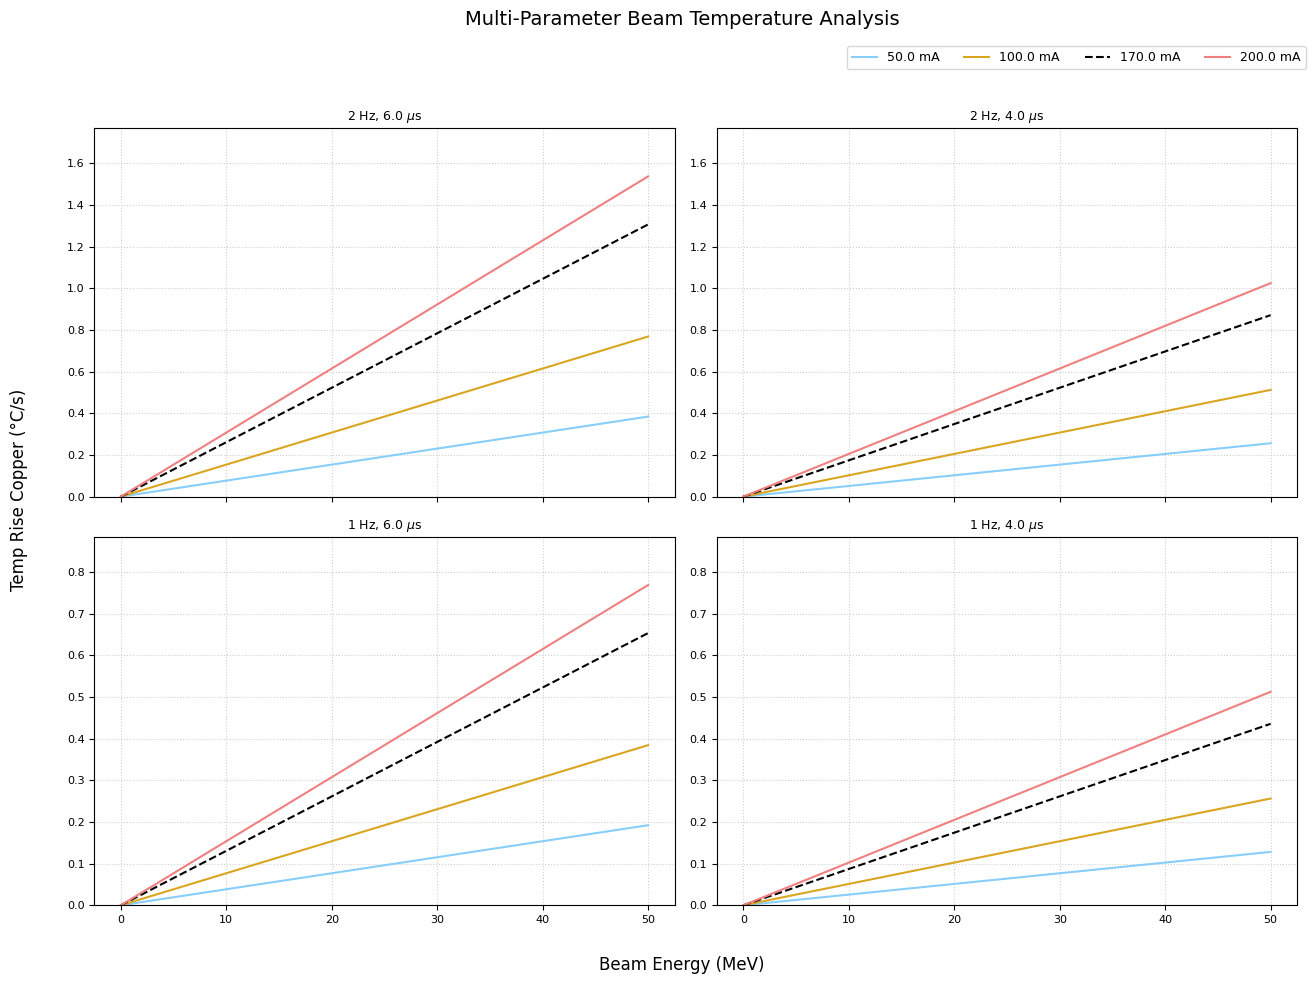

,Energy (MeV),Beam Current (mA),Repetition Rate (Hz),Pulse Duration (us),Power (W),Temp Rise Copper (C/s),Temp Rise Aluminum (C/s),Temp Rise Stainless Steel (C/s)
0,0.0,50.0,1.0,4.0,0.000000,0.000000,0.000000,0.000000
1,0.0,100.0,1.0,4.0,0.000000,0.000000,0.000000,0.000000
2,0.0,170.0,1.0,4.0,0.000000,0.000000,0.000000,0.000000
3,0.0,200.0,1.0,4.0,0.000000,0.000000,0.000000,0.000000
4,0.0,50.0,1.0,6.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
1595,50.0,200.0,2.0,4.0,80.000008,1.025272,1.460331,0.901090
1596,50.0,50.0,2.0,6.0,30.000002,0.384477,0.547624,0.337909
1597,50.0,100.0,2.0,6.0,60.000004,0.768954,1.095249,0.675817
1598,50.0,170.0,2.0,6.0,102.000008,1.307221,1.861923,1.148889


In [77]:
obj = beamUtility()
obj.chargePerMacropulse(torch.linspace(0, 200e-3, 50), torch.tensor([2.0e-6, 5.0e-6, 8.0e-6]))
obj.getPowerDF(np.array([50e-3, 100e-3, 170e-3, 200e-3]), np.array([4.0, 6.0]),
                       rep_rate_values = np.array([1, 2]), E_energy_range = np.linspace(0, 50, 100),plot_type = "Temperature")

In [78]:
model_b2=obj.model_Bethe("Copper", np.linspace(0.1, 50, 100))
print(model_b1)
print(model_b2)

cols_to_check = ["Energy (MeV)", "Penetration Depth (cm)", "Stopping Power (MeV/mm)"]


comparison = np.allclose(model_b1["Penetration Depth (cm)"],
                         model_b2["Penetration Depth (cm)"])

print(f"Results are close: {comparison}")

   Material  Energy (MeV)  Penetration Depth (cm)  Stopping Power (MeV/mm)
0    Copper      0.100000                0.001557                 6.422267
1    Copper      0.604040                0.021670                 2.787514
2    Copper      1.108081                0.044563                 2.486575
3    Copper      1.612121                0.067451                 2.390071
4    Copper      2.116162                0.090190                 2.346325
..      ...           ...                     ...                      ...
95   Copper     47.983838                2.115104                 2.268628
96   Copper     48.487879                2.137326                 2.268624
97   Copper     48.991919                2.159548                 2.268619
98   Copper     49.495960                2.181770                 2.268615
99   Copper     50.000000                2.203992                 2.268611

[100 rows x 4 columns]
   Material  Energy (MeV)  Penetration Depth (cm)  Stopping Power (MeV/mm)
0

In [80]:
x2,decom2=obj.compute_deposition_profile(10, "Copper")
print(x2, decom2)

print(np.allclose(x1,x2))

print(np.allclose(decom1,decom2))

tensor([0.0000, 0.0246, 0.0493, 0.0739, 0.0986, 0.1232, 0.1479, 0.1725, 0.1972,
        0.2218, 0.2465, 0.2711, 0.2957, 0.3204, 0.3450, 0.3697, 0.3943, 0.4190,
        0.4436, 0.4683, 0.4929, 0.5176, 0.5422, 0.5669, 0.5915, 0.6161, 0.6408,
        0.6654, 0.6901, 0.7147, 0.7394, 0.7640, 0.7887, 0.8133, 0.8380, 0.8626,
        0.8872, 0.9119, 0.9365, 0.9612, 0.9858, 1.0105, 1.0351, 1.0598, 1.0844,
        1.1091, 1.1337, 1.1583, 1.1830, 1.2076, 1.2323, 1.2569, 1.2816, 1.3062,
        1.3309, 1.3555, 1.3802, 1.4048, 1.4295, 1.4541, 1.4787, 1.5034, 1.5280,
        1.5527, 1.5773, 1.6020, 1.6266, 1.6513, 1.6759, 1.7006, 1.7252, 1.7498,
        1.7745, 1.7991, 1.8238, 1.8484, 1.8731, 1.8977, 1.9224, 1.9470, 1.9717,
        1.9963, 2.0209, 2.0456, 2.0702, 2.0949, 2.1195, 2.1442, 2.1688, 2.1935,
        2.2181, 2.2428, 2.2674, 2.2921, 2.3167, 2.3413, 2.3660, 2.3906, 2.4153,
        2.4399], dtype=torch.float64) tensor([ 3.7299e-06,  1.4552e-05,  5.2488e-05,  1.7504e-04,  5.3966e-04,
         